In [7]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
from helper_utils import load_chroma, word_wrap, project_embeddings
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

In [2]:
embedding_function = SentenceTransformerEmbeddingFunction()

chroma_collection = load_chroma(filename='sample.pdf', collection_name='sample', embedding_function=embedding_function)
chroma_collection.count()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

7

In [16]:
import os
from dotenv import load_dotenv, find_dotenv
from groq import Groq

_ = load_dotenv(find_dotenv())

groq_client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)

In [17]:
import umap

embeddings = chroma_collection.get(include=['embeddings'])['embeddings']
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

100%|██████████| 7/7 [00:00<00:00, 154.56it/s]


In [18]:
def augment_query_generated(query, model="llama-3.3-70b-versatile"):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert AI assistant. "
                "Generate a detailed hypothetical answer to the user's question. "
                "The answer does not need to be factually correct. "
                "It should sound like a relevant document that could contain the answer."
            )
        },
        {
            "role": "user",
            "content": query
        }
    ]

    response = groq_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0
    )

    return response.choices[0].message.content

In [19]:
original_query = "How does ChromaDB support retrieval augmented generation?"
hypothetical_answer = augment_query_generated(original_query)

joint_query = f"{original_query} {hypothetical_answer}"
print(word_wrap(joint_query))

How does ChromaDB support retrieval augmented generation? **ChromaDB
Technical Brief: Retrieval Augmented
Generation**

**Introduction**

ChromaDB is a cutting-edge, multimodal
database management system designed to support a wide range of
applications, including retrieval augmented generation. This technical
brief provides an overview of how ChromaDB supports retrieval augmented
generation, a technique that combines the strengths of generative
models and retrieval-based approaches to produce high-quality,
context-dependent outputs.

**Retrieval Augmented Generation
Overview**

Retrieval augmented generation is a technique that involves
using a database to retrieve relevant information and then using a
generative model to produce an output based on the retrieved
information. This approach has been shown to be effective in a variety
of applications, including text generation, image captioning, and
dialogue systems.

**ChromaDB Architecture**

ChromaDB is designed to
support retrieval au

In [20]:
results = chroma_collection.query(query_texts=joint_query, n_results=5, include=['documents', 'embeddings'])
retrieved_documents = results['documents'][0]

for doc in retrieved_documents:
    print(word_wrap(doc))
    print('')

mathematically similar to the query vector, effectively finding content
that is semantically related rather than just keyword - matched. this
makes chromadb far more powerful than traditional databases for tasks
involving natural language understanding, recommendation systems,
semantic search, and context retrieval in ai - driven applications. how
chromadb works the fundamental building block of chromadb is the
collection, which is roughly equivalent to a table in a traditional
relational database. each collection holds a set of documents, their
corresponding vector embeddings, and any metadata the developer wishes
to attach. when data is added to a collection, chromadb can generate
the embeddings automatically using a built - in embedding function, or
it can accept pre - computed embeddings from an external model. this
flexibility allows developers to work with any embedding model they
prefer, whether that is openai ' s text - embedding models, sentence

chromadb : an overview introdu

In [21]:
retrieved_embeddings = results['embeddings'][0]
original_query_embedding = embedding_function([original_query])
augmented_query_embedding = embedding_function([joint_query])

projected_original_query_embedding = project_embeddings(original_query_embedding, umap_transform)
projected_augmented_query_embedding = project_embeddings(augmented_query_embedding, umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)

100%|██████████| 5/5 [00:00<00:00, 250.80it/s]


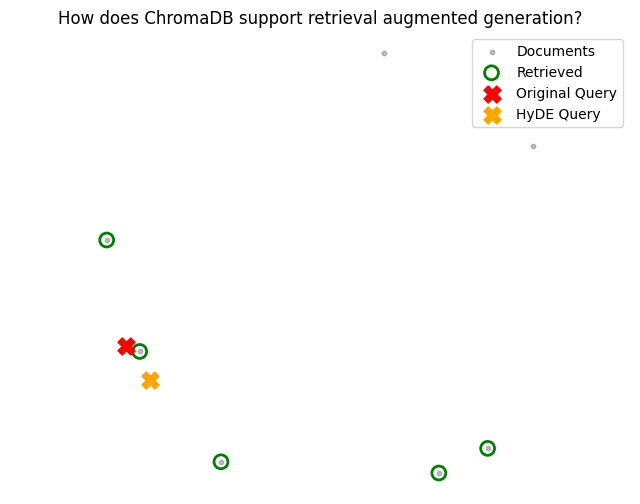

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# All document chunks
plt.scatter(
    projected_dataset_embeddings[:, 0],
    projected_dataset_embeddings[:, 1],
    s=10,
    color='gray',
    alpha=0.5,
    label='Documents'
)

# Retrieved documents
plt.scatter(
    projected_retrieved_embeddings[:, 0],
    projected_retrieved_embeddings[:, 1],
    s=100,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Retrieved'
)

# Original query
plt.scatter(
    projected_original_query_embedding[:, 0],
    projected_original_query_embedding[:, 1],
    s=150,
    marker='X',
    color='red',
    label='Original Query'
)

# HyDE augmented query
plt.scatter(
    projected_augmented_query_embedding[:, 0],
    projected_augmented_query_embedding[:, 1],
    s=150,
    marker='X',
    color='orange',
    label='HyDE Query'
)

plt.gca().set_aspect('equal', 'datalim')
plt.title(original_query)
plt.legend()
plt.axis('off')
plt.show()

In [25]:
def augment_multiple_query(query, model="llama-3.3-70b-versatile"):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert AI and vector database assistant. "
                "Given a user's question, generate up to five related questions "
                "that would help retrieve relevant information from a knowledge base. "
                "Questions should be short, complete, and cover different aspects "
                "of the topic. Output one question per line. "
                "Do not number the questions."
            )
        },
        {
            "role": "user",
            "content": query
        }
    ]

    response = groq_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0
    )

    return response.choices[0].message.content.split("\n")

In [26]:
original_query = "How does ChromaDB support retrieval augmented generation?"

augmented_queries = augment_multiple_query(original_query)

for q in augmented_queries:
    print(q)

What is retrieval augmented generation and its key components?
How does ChromaDB integrate with language models for generation tasks?
What indexing methods does ChromaDB use to support efficient retrieval?
Can ChromaDB handle multi-modal data for retrieval augmented generation?
How does ChromaDB's vector database architecture facilitate generation workflows?


In [27]:
queries = [original_query] + augmented_queries
results = chroma_collection.query(query_texts=queries, n_results=5, include=['documents', 'embeddings'])

retrieved_documents = results['documents']

# Deduplicate the retrieved documents
unique_documents = set()
for documents in retrieved_documents:
    for document in documents:
        unique_documents.add(document)

for i, documents in enumerate(retrieved_documents):
    print(f"Query: {queries[i]}")
    print('')
    print("Results:")
    for doc in documents:
        print(word_wrap(doc))
        print('')
    print('-'*100)

Query: How does ChromaDB support retrieval augmented generation?

Results:
transformers from hugging face, or any other provider. querying in
chromadb is done through a nearest - neighbor search, which finds the
vectors that are closest to a given query vector according to a
distance metric such as cosine similarity or euclidean distance. the
results include not only the most relevant documents but also their
metadata and similarity scores, giving developers everything they need
to build rich, context - aware applications. chromadb supports
filtering on metadata as well, which means developers can narrow search
results by date, category, author, or any other attribute stored
alongside the vectors. chromadb can be run in two primary modes. the
first is an in - memory mode, which is ideal for prototyping and
development because data is stored temporarily and lost when the
application shuts down. the second is a persistent mode, where data is
saved to disk and survives between sessions. f

In [28]:
original_query_embedding = embedding_function([original_query])
augmented_query_embeddings = embedding_function(augmented_queries)

project_original_query = project_embeddings(original_query_embedding, umap_transform)
project_augmented_queries = project_embeddings(augmented_query_embeddings, umap_transform)


100%|██████████| 5/5 [00:00<00:00, 224.56it/s]


In [29]:
result_embeddings = results['embeddings']
result_embeddings = [item for sublist in result_embeddings for item in sublist]
projected_result_embeddings = project_embeddings(result_embeddings, umap_transform)


100%|██████████| 30/30 [00:00<00:00, 251.88it/s]


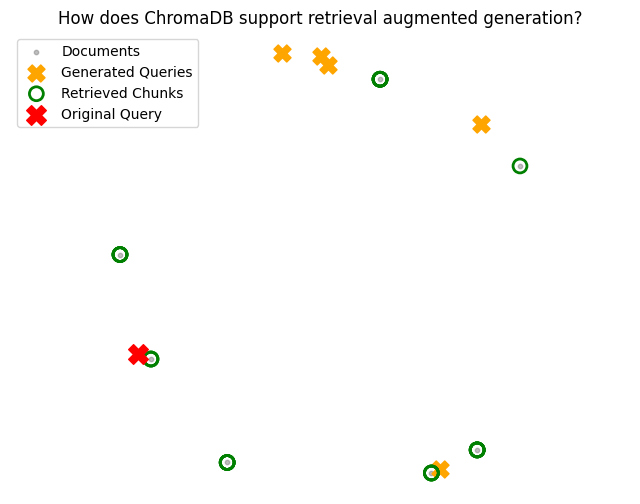

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# All document chunks
plt.scatter(
    projected_dataset_embeddings[:, 0],
    projected_dataset_embeddings[:, 1],
    s=10,
    color='gray',
    alpha=0.5,
    label='Documents'
)

# Generated queries
plt.scatter(
    project_augmented_queries[:, 0],
    project_augmented_queries[:, 1],
    s=150,
    marker='X',
    color='orange',
    label='Generated Queries'
)

# Retrieved documents
plt.scatter(
    projected_result_embeddings[:, 0],
    projected_result_embeddings[:, 1],
    s=100,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Retrieved Chunks'
)

# Original query
plt.scatter(
    project_original_query[:, 0],
    project_original_query[:, 1],
    s=200,
    marker='X',
    color='red',
    label='Original Query'
)

plt.gca().set_aspect('equal', 'datalim')
plt.title(original_query)
plt.legend()
plt.axis('off')
plt.show()